In [153]:
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt 

In [154]:
raw_train_data = pd.read_csv('titanic/train.csv')

In [155]:
raw_train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We begin by investigating the data.
Initial ideas:
Women and children were likely to be evacuated, men were not. This is from my historical understanding.

For other passengers, I am not sure if there was any difference in treatment. Perhaps upper class were more likely to be evacuated. Perhaps this could also correspond with the location within the ship.

We probably should therefore investigate the cabins.
Likely passengers who boarded in Cherbourg are more likely to be French speakers. Perhaps they are more likely to pass away due to lack of knowledge of English and therefore would have had a poorer understanding of what was happening around them. Alternatively perhaps they were given better treatment because of this by their fellow passengers who were sympathetic to their situation.

Names are probably fairly irrelevant, except for possible classification as French or British, and maybe social class. We already have Pclass and Embarked locations however, which might be stronger predictors of this.

Notes:
I want to keep not that many factors. There's only 800 data points for training, so overfitting could be a problem.

<Axes: xlabel='Age'>

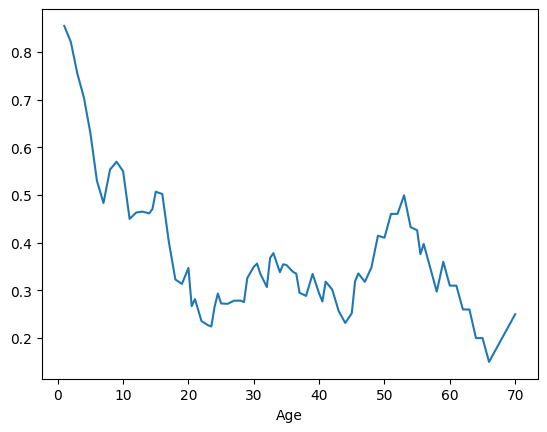

In [156]:
raw_train_data.groupby("Age")["Survived"].mean().rolling(window = 10, center = True).mean().plot()

Initial thoughts are, it's not clear why they let so many 8 year olds die. Is this just pure coincidence?
I think however it's clear I should try aggregating each of the ages into buckets. I should choose the buckets carefully. I used a rolling window of 5 years above. So each plot point should be viewed as the probability of surviving for the 5 years below the shown age.

It seems from about age 50 onwards there's a large increase in survival probability, but this drops off after 55 or so. 

I will try a 5 year grouping.


In [157]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]

def add_buckets(train_data, bins, key):
    bucket_ids = np.digitize(train_data[key], bins)
    train_data[f"{key}_bucket_id"] = bucket_ids
    return train_data

In [158]:
working_train_data = add_buckets(raw_train_data, bins, "Age")

In [159]:
working_train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_bucket_id
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,4
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,4
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,4


Does this analysis change much if we look at men and women separately:

<Axes: xlabel='Age'>

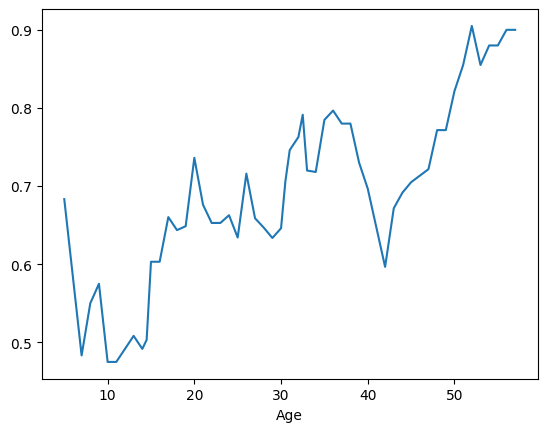

In [160]:
raw_train_data[raw_train_data["Sex"] == "female"].groupby("Age")["Survived"].mean().rolling(window = 10, center = True).mean().plot()

<Axes: xlabel='Age'>

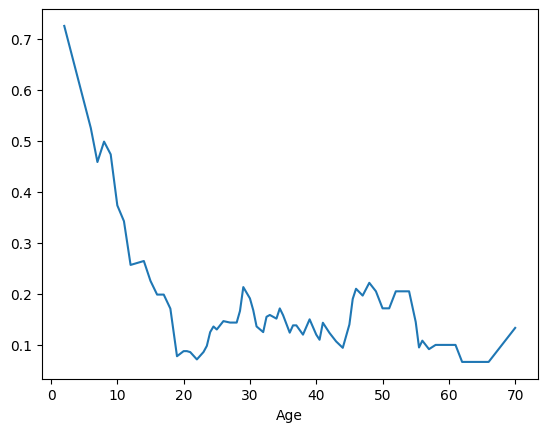

In [161]:
raw_train_data[raw_train_data["Sex"] == "male"].groupby("Age")["Survived"].mean().rolling(window = 10, center = True).mean().plot()

Yes! Older women are actually more likely to survive than the younger girls... Perhaps among those who could go onto the boats, those that had more authority were better able to do so.

We knew this would be an important feature, it's surprising to see what a big differece it has though. We will try and do one shot encoding on this to reflect it's importance.

Is there a difference among the age profiles between classes?

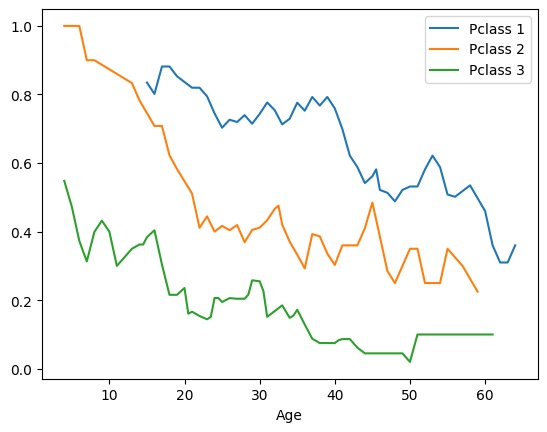

In [162]:
for i in range(1, 4):
    raw_train_data[raw_train_data["Pclass"] == i].groupby("Age")["Survived"].mean().rolling(window = 10, center = True).mean().plot(label = f"Pclass {i}")
plt.legend()

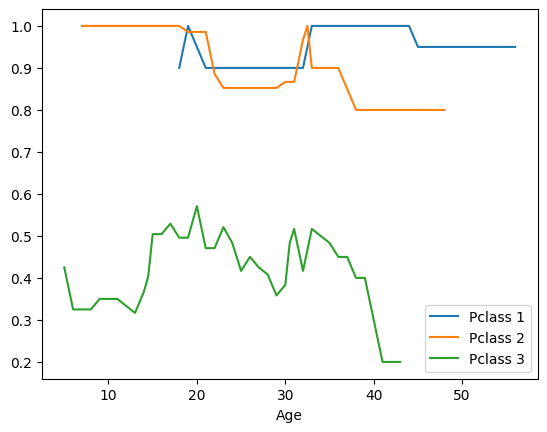

In [163]:
for i in range(1, 4):
    raw_train_data[(raw_train_data["Pclass"] == i) & (raw_train_data["Sex"] == "female")].groupby("Age")["Survived"].mean().rolling(window = 10, center = True).mean().plot(label = f"Pclass {i}")
plt.legend()

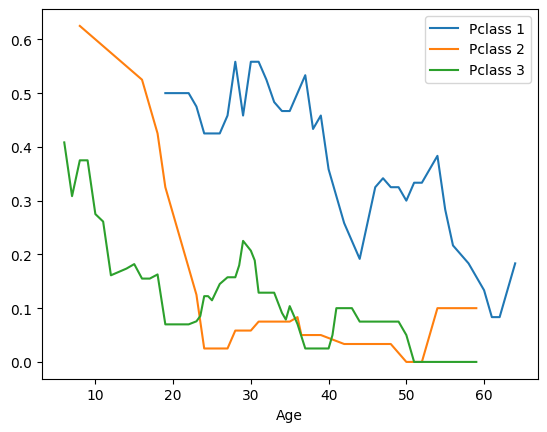

In [164]:
for i in range(1, 4):
    raw_train_data[(raw_train_data["Pclass"] == i) & (raw_train_data["Sex"] == "male")].groupby("Age")["Survived"].mean().rolling(window = 10, center = True).mean().plot(label = f"Pclass {i}")
plt.legend()

Class also seems very important. If you were female and in the 1st or 2nd class, it seems your chance of surviving was quite high. Probably for these we can predict that they survived quite easily.

Simily for men in classes 2 or 3 over aged 20 or so, it seems around 90% passed away. So again we can predict they died.

Wwe should therefore focus our attention on trying to find discriminating features for class 1 men, and class 3 women. Who are largely between 50 50 in many cases.

In [165]:
class_1_men_data = raw_train_data[(raw_train_data["Pclass"] == 1) & (raw_train_data["Sex"] == "male")]
class_1_men_data.sort_values("Survived", inplace = True)
class_3_women_data = raw_train_data[(raw_train_data["Pclass"] == 3) & (raw_train_data["Sex"] == "female")]
class_3_women_data.sort_values("Survived", inplace = True)

C:\Users\rapto\AppData\Local\Temp\ipykernel_13908\576196009.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  class_1_men_data.sort_values("Survived", inplace = True)
C:\Users\rapto\AppData\Local\Temp\ipykernel_13908\576196009.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  class_3_women_data.sort_values("Survived", inplace = True)


In [166]:
pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)

     PassengerId  Survived  Pclass                               Name   Sex  \
6              7         0       1            McCarthy, Mr. Timothy J  male   
555          556         0       1                 Wright, Mr. George  male   
545          546         0       1       Nicholson, Mr. Arthur Ernest  male   
544          545         0       1         Douglas, Mr. Walter Donald  male   
536          537         0       1  Butt, Major. Archibald Willingham  male   

      Age  SibSp  Parch    Ticket      Fare Cabin Embarked  Age_bucket_id  
6    54.0      0      0     17463   51.8625   E46        S              6  
555  62.0      0      0    113807   26.5500   NaN        S              7  
545  64.0      0      0       693   26.0000   NaN        S              7  
544  50.0      1      0  PC 17761  106.4250   C86        C              6  
536  45.0      0      0    113050   26.5500   B38        S              5  


<Axes: xlabel='Survived'>

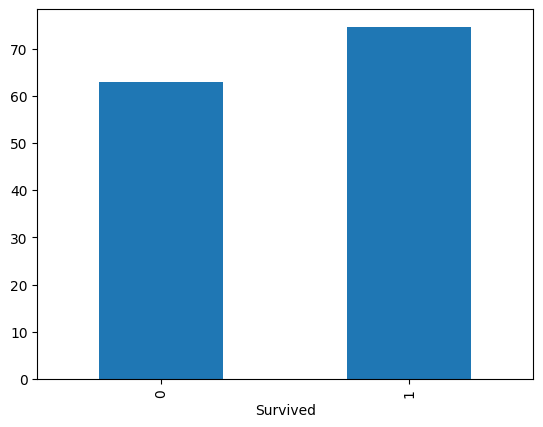

In [167]:
print(class_1_men_data.head())

class_1_men_data.groupby("Survived")["Fare"].mean().plot(kind = "bar")


C:\Users\rapto\AppData\Local\Temp\ipykernel_13908\619748775.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[f"{key}_bucket_id"] = bucket_ids


<Axes: xlabel='Fare_bucket_id'>

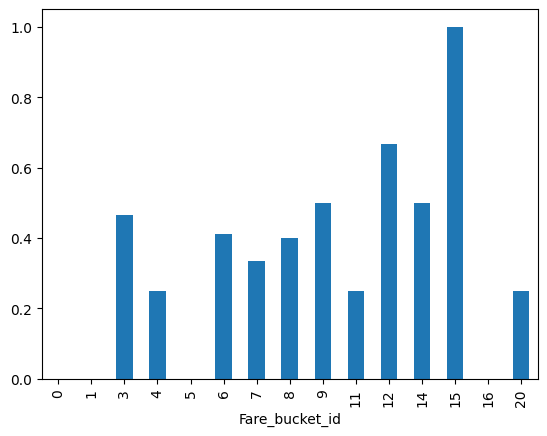

In [168]:

men_with_bucket = add_buckets(class_1_men_data, [x*10 + 2 for x in range (20)], "Fare")
men_with_bucket.groupby("Fare_bucket_id")["Survived"].mean().plot(kind = "bar")

C:\Users\rapto\AppData\Local\Temp\ipykernel_13908\619748775.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[f"{key}_bucket_id"] = bucket_ids


<Axes: xlabel='Fare_bucket_id'>

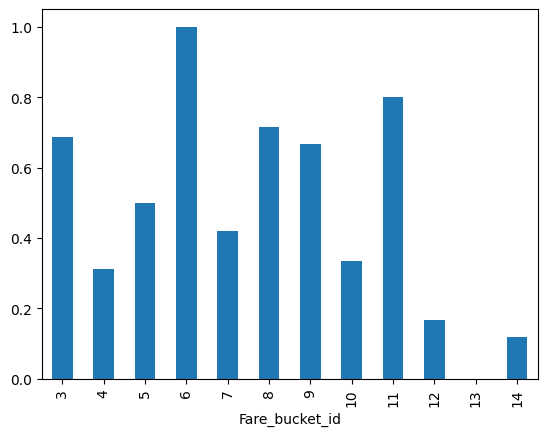

In [169]:
women_with_bucket = add_buckets( class_3_women_data, [x*2 + 2 for x in range (14)],"Fare")
women_with_bucket.groupby("Fare_bucket_id")["Survived"].mean().plot(kind = "bar")

<Axes: xlabel='Fare'>

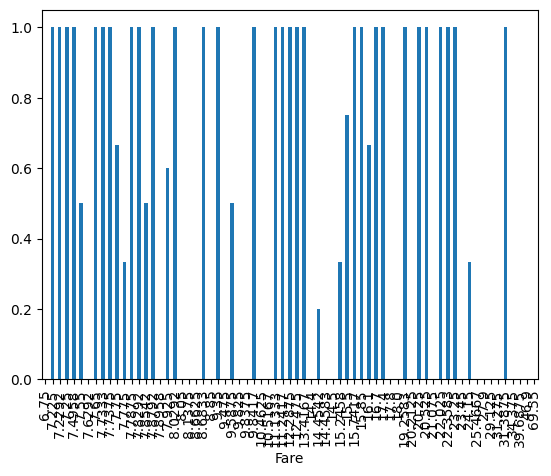

In [170]:
class_3_women_data.groupby("Fare")["Survived"].mean().plot(kind = "bar")

<Axes: xlabel='Survived'>

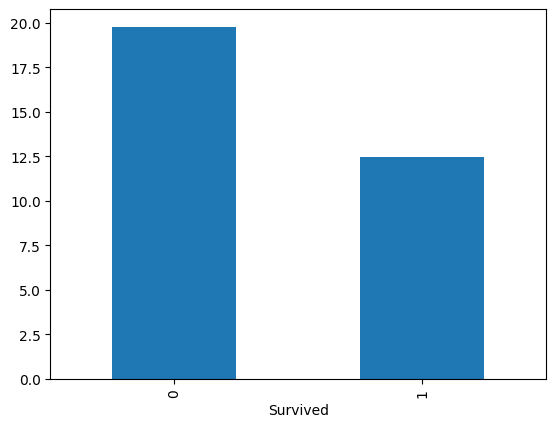

In [171]:
class_3_women_data.groupby("Survived")["Fare"].mean().plot(kind = "bar")

The fare doesn't seem to explain much, at least in how I've looked at it here. 

Let's consider instead the number of siblings and parents, children. Perhaps if you had children you were more likely to be saved with them. I would imagine this is more true for the first class men as well, as their children are more likely to have survived as seen previously.

<Axes: xlabel='SibSp'>

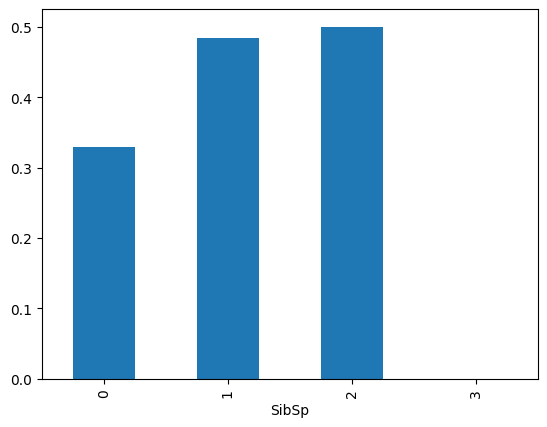

In [172]:
class_1_men_data.groupby("SibSp")["Survived"].mean().plot(kind = "bar")   

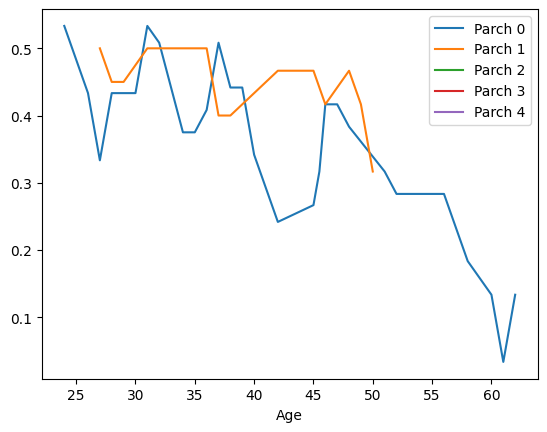

In [173]:
for i in range(0, 5):
    raw_train_data[(raw_train_data["Pclass"] == 1) & (raw_train_data["Sex"] == "male") & (raw_train_data["SibSp"] == i)].groupby("Age")["Survived"].mean().rolling(window = 10, center = True).mean().plot(label = f"Parch {i}")
plt.legend()

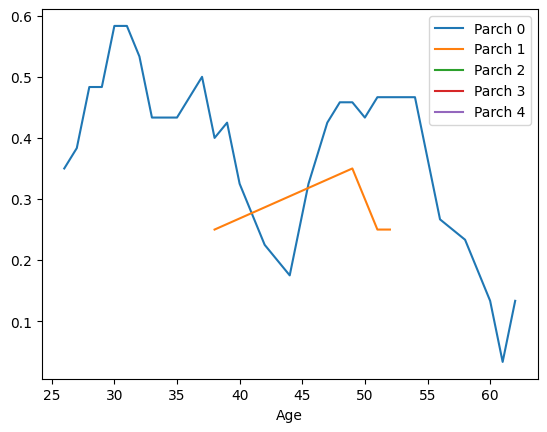

In [174]:
for i in range(0, 5):
    raw_train_data[(raw_train_data["Pclass"] == 1) & (raw_train_data["Sex"] == "male") & (raw_train_data["Parch"] == i)].groupby("Age")["Survived"].mean().rolling(window = 10, center = True).mean().plot(label = f"Parch {i}")
plt.legend()

<Axes: xlabel='SibSp'>

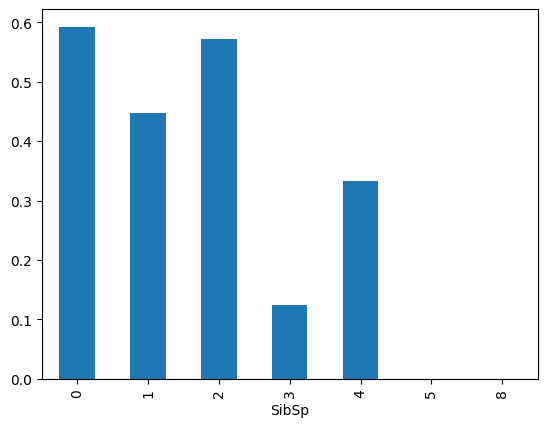

In [175]:
class_3_women_data.groupby("SibSp")["Survived"].mean().plot(kind = "bar")   

<Axes: xlabel='Parch'>

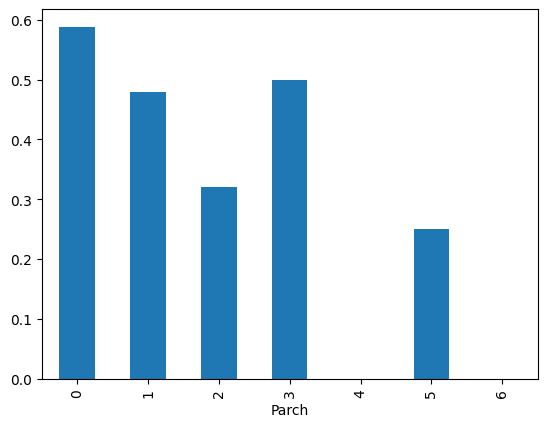

In [176]:
class_3_women_data.groupby("Parch")["Survived"].mean().plot(kind = "bar")   

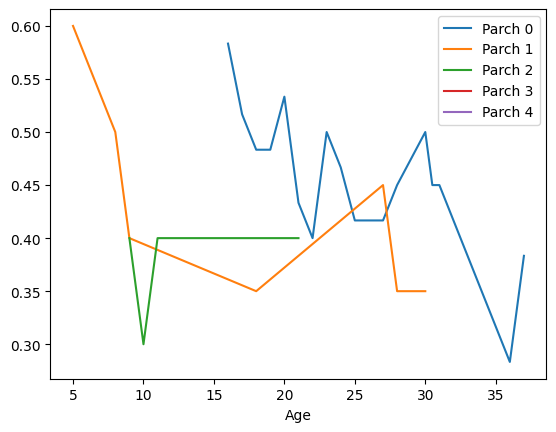

In [177]:
for i in range(0, 5):
    raw_train_data[(raw_train_data["Pclass"] == 3) & (raw_train_data["Sex"] == "female") & (raw_train_data["Parch"] == i)].groupby("Age")["Survived"].mean().rolling(window = 10, center = True).mean().plot(label = f"Parch {i}")
plt.legend()

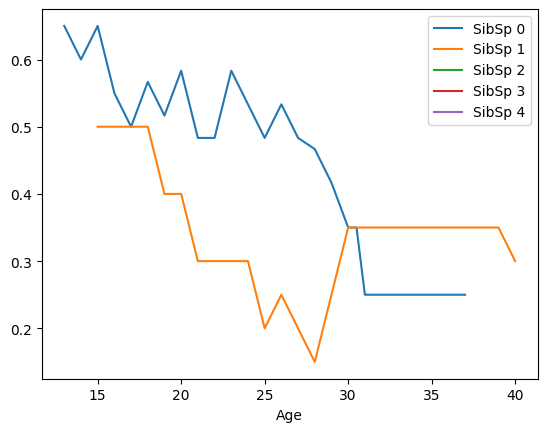

In [178]:
for i in range(0, 5):
    raw_train_data[(raw_train_data["Pclass"] == 3) & (raw_train_data["Sex"] == "female") & (raw_train_data["SibSp"] == i)].groupby("Age")["Survived"].mean().rolling(window = 10, center = True).mean().plot(label = f"SibSp {i}")
plt.legend()

The above does seem to be a pretty important feature for Women. There's a clear slop to this plot which is apparent for the men as well.

So it seems siblings etc are of greater importance in this case.

Finally let's consider the port of embarkation. Queenstown are likely to be the poorest, Cherbourg richer.

<Axes: xlabel='Embarked'>

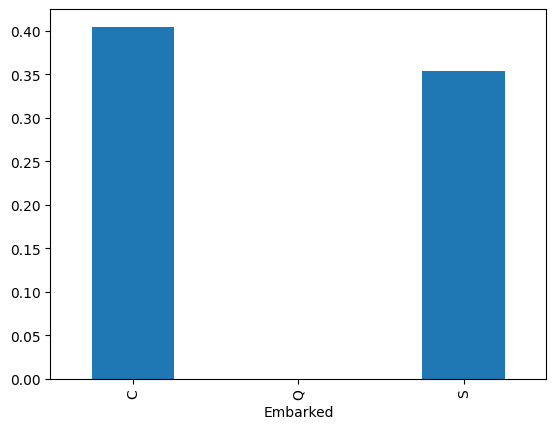

In [179]:
class_1_men_data.groupby("Embarked")["Survived"].mean().plot(kind = "bar")

<Axes: xlabel='Embarked'>

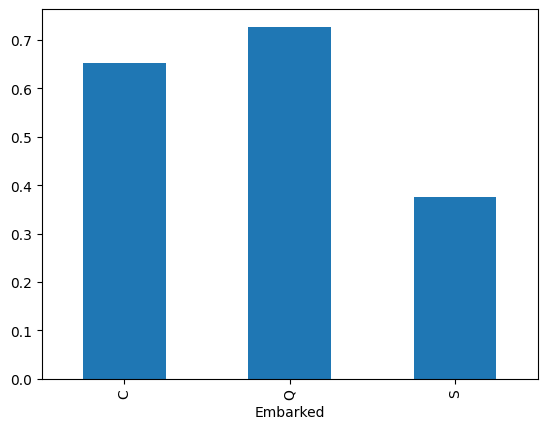

In [180]:
class_3_women_data.groupby("Embarked")["Survived"].mean().plot(kind = "bar")

This does seem to be fairly predictive for the class 3 women. It's surprising to me that those from Southampton were less likely to die. Perhaps I have some misconception here about Britain at that time, and the passengers that boarded from each place.

Let's look at the total distribution of fares, and then create quantiles based on these fares for bucketing:

<Axes: ylabel='Frequency'>

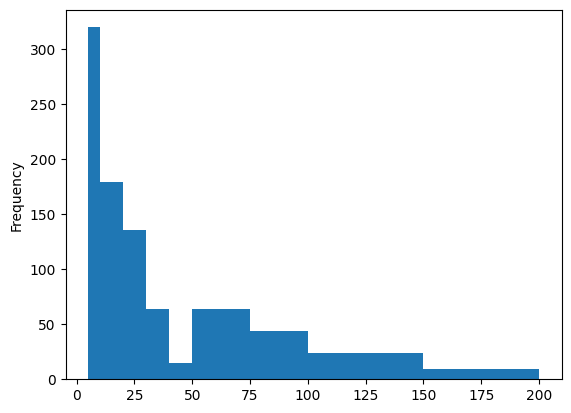

In [181]:
raw_train_data["Fare"].plot(kind = "hist", bins = [5, 10, 20, 30, 40, 50, 75, 100, 150, 200])

In [ ]:
def get_processed_frame(raw_train_data):

    df_encoded = pd.get_dummies(raw_train_data, columns = ["Sex", "Embarked"], drop_first=True)

    df_encoded = add_buckets(df_encoded, [0, 10, 20, 30, 40, 50, 60, 70, 80], "Age")

    df_encoded = add_buckets(df_encoded, [5, 10, 20, 30, 40, 50, 75, 100, 150, 200], "Fare")
    df_encoded.drop(columns = ["Name", "Ticket", "Cabin", "Age", "Fare"], inplace = True)

    return df_encoded

In [ ]:
df_encoded = get_processed_frame(raw_train_data)


In [184]:
print(df_encoded.head())

   PassengerId  Survived  Pclass  SibSp  Parch  Age_bucket_id  Sex_male  \
0            1         0       3      1      0              3      True   
1            2         1       1      1      0              4     False   
2            3         1       3      0      0              3     False   
3            4         1       1      1      0              4     False   
4            5         0       3      0      0              4      True   

   Embarked_Q  Embarked_S  Fare_bucket_id  
0       False        True               1  
1       False       False               6  
2       False        True               1  
3       False        True               6  
4       False        True               1  


In [185]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

passenger_ids = df_encoded["PassengerId"]

# -----------------------------
# Features / target
# -----------------------------

X = df_encoded.drop(columns=["Survived", "PassengerId"])
y = df_encoded["Survived"]

# -----------------------------
# Split
# -----------------------------

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Model
# -----------------------------

model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# -----------------------------
# Train
# -----------------------------

model.fit(X_train, y_train)

# -----------------------------
# Predict
# -----------------------------

preds = model.predict(X_valid)

# -----------------------------
# Accuracy
# -----------------------------

accuracy = accuracy_score(y_valid, preds)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8212


In [ ]:
raw_test_data = pd.read_csv('titanic/test.csv')

df_test_encoded = get_processed_frame(raw_test_data)

test_passenger_ids = df_test_encoded["PassengerId"]

X_test = df_encoded.drop(columns=["PassengerId"])
preds = model.predict(df_encoded)

In [ ]:
return_frame = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": preds
})

In [ ]:
return_frame.to_csv("submission.csv", index = False)